In [1]:
import librosa
from moviepy.video.io.VideoFileClip import VideoFileClip
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

In [ ]:
# Load video and save audio as WAV file

data_path = "/Users/vickyxu/Desktop/B2S/Final_datafiles"
covert_data_filename = "B2S_Pilot1_Spoken_20241119_022612.mff"
covert_video_filename = "B2S_Pilot1_Spoken_20241119_022612.mov"

video_file = os.path.join(data_path, covert_data_filename, covert_video_filename)
video = VideoFileClip(video_file)

# Save audio to WAV file
video.audio.write_audiofile("../overt_audio.wav")

In [ ]:
# Load WAV and detect voice onset

y, sr = librosa.load("../overt_audio.wav")
print("Audio sampling rate: ", sr)

onset_env = librosa.onset.onset_strength(y=y, sr=sr)

# detect onset in frames
onsets = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)

# Convert to seconds
onset_times = librosa.frames_to_time(onsets, sr=sr)

print("Onset times (s):", onset_times)
print("Num of onsets:", len(onset_times))

Audio sampling rate:  22050
Onset times (s): [6.96598639e-02 4.85297052e+00 6.06040816e+00 6.26938776e+00
 8.75392290e+00 8.87002268e+00 2.06657596e+01 2.40790930e+01
 2.42184127e+01 2.92803628e+01 3.30187755e+01 3.77788662e+01
 4.11921995e+01 4.94817234e+01 4.97603628e+01 5.38238549e+01
 6.08827211e+01 6.45979138e+01 6.86381859e+01 7.24230385e+01
 7.69044898e+01 9.15562812e+01 9.18581406e+01 9.64324717e+01
 9.68039909e+01 1.00333424e+02 1.04048617e+02 1.07647710e+02
 1.11479002e+02 1.15170975e+02 1.27082812e+02 1.31285624e+02
 1.35697415e+02 1.43127800e+02 1.46750113e+02 1.48259410e+02
 1.48421950e+02 1.51742404e+02 1.58894150e+02 1.66881814e+02
 1.75287438e+02 1.78932971e+02 1.85945397e+02 1.86711655e+02
 1.98368073e+02 2.03383583e+02 2.08584853e+02 2.12183946e+02
 2.15527619e+02 2.15852698e+02 2.20194830e+02 2.23654603e+02
 2.30063311e+02 2.30458050e+02 2.49753832e+02 2.53631565e+02
 2.56789478e+02 2.60388571e+02 2.60574331e+02 2.64289524e+02
 2.66123900e+02 2.68492336e+02 2.7183600

In [5]:
diffs = np.diff(np.array(onset_times))
print(diffs)

[ 4.78331066  1.20743764  0.20897959  2.48453515  0.11609977 11.79573696
  3.41333333  0.13931973  5.06195011  3.7384127   4.7600907   3.41333333
  8.28952381  0.27863946  4.06349206  7.05886621  3.71519274  4.04027211
  3.78485261  4.48145125 14.65179138  0.30185941  4.57433107  0.37151927
  3.52943311  3.71519274  3.59909297  3.83129252  3.69197279 11.91183673
  4.20281179  4.41179138  7.43038549  3.62231293  1.50929705  0.16253968
  3.32045351  7.15174603  7.9876644   8.40562358  3.64553288  7.0124263
  0.7662585  11.65641723  5.0155102   5.20126984  3.59909297  3.34367347
  0.32507937  4.34213152  3.45977324  6.40870748  0.39473923 19.29578231
  3.87773243  3.15791383  3.59909297  0.18575964  3.71519274  1.83437642
  2.36843537  3.34367347 11.09913832  3.29723356  4.08671202  3.78485261
  0.16253968  4.27247166  4.43501134 13.04961451  0.23219955  3.11147392
  0.18575964  3.7384127   7.12852608  6.33904762  8.52172336  1.46285714
  0.16253968  3.32045351  3.29723356  2.55419501 21.

In [12]:
# Load audio
y, sr = librosa.load("../overt_audio.wav")

# Z-score the signal
y_z = (y - np.mean(y)) / np.std(y)

# Parameters
window_ms = 300
win_samples = int(sr * window_ms / 1000)
threshold = 1.2  # z-scored energy threshold

# Compute energy envelope using moving sum of squared signal
energy = np.convolve(y_z**2, np.ones(win_samples), mode='same')
energy_z = (energy - np.mean(energy)) / np.std(energy)

# Detect voice onset
voiced = np.where(energy_z > threshold)[0]

# Find the difference between consecutive values
diffs = np.diff(voiced)

# Where the gap is more than 1, a new segment starts
segment_starts = np.insert(diffs > 1, 0, True)  # Always include the first index

# Get the indices of the starts
voiced_onsets = voiced[segment_starts]

voiced_onsets_times = voiced_onsets / sr

In [10]:
len(voiced_onsets_times)

131

In [13]:
print(f"Voice onset at {voiced_onsets_times}")

Voice onset at [  4.86598639   8.83913832  13.05501134  16.29977324  20.41904762
  24.37088435  29.09673469  32.79160998  41.09668934  41.10131519
  44.81528345  49.69269841  53.69165533  57.32802721  60.64680272
  64.82176871  72.7968254   76.94603175  80.79319728  84.27519274
  88.2492517   91.9892517   92.05346939  96.69197279 103.98575964
 111.44222222 115.2875737  120.16117914 123.44698413 127.25301587
 127.25310658 131.18988662 135.65995465 139.55959184 143.42725624
 148.44154195 151.70997732 163.46435374 163.65061224 167.05015873
 167.27900227 170.31809524 175.29365079 178.88789116 183.4985034
 186.58290249 190.74666667 195.09287982 198.69360544 203.80054422
 208.60426304 212.58956916 215.87537415 223.71369615 227.22385488
 230.51773243 234.58712018 238.84090703 242.42340136 246.24639456
 249.79124717 253.4938322  256.93147392 260.630839   264.36439909
 268.28743764 271.92195011 275.31510204 279.01369615 282.76752834
 286.35138322 290.330839   294.16630385 298.4770068  303.22952

/Users/vickyxu/Desktop/B2S/B2S-EEG-Analysis/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


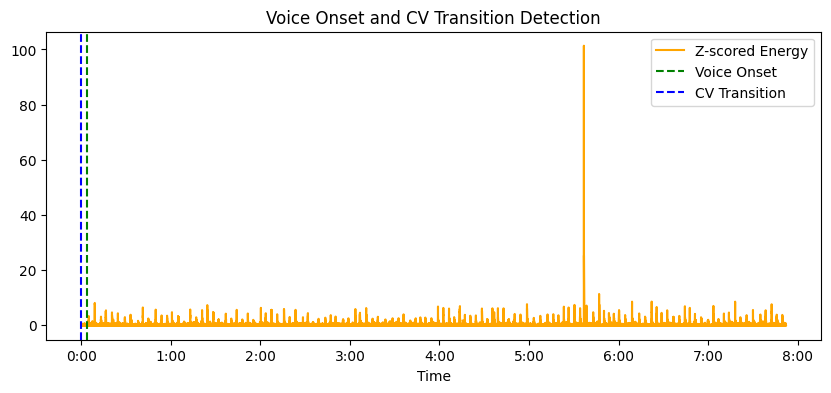

Voice onset at 4.022s
CV transition at 0.000s


In [10]:
# Define duration to plot (in seconds)
duration_sec = 20
samples_to_plot = int(sr * duration_sec)

# Plotting
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y[:samples_to_plot], sr=sr, alpha=0.5)
plt.plot(np.arange(len(energy_z)) / sr, energy_z, label='Z-scored Energy', color='orange')
if onset_time:
    plt.axvline(onset_time, color='green', linestyle='--', label='Voice Onset')
plt.axvline(transition_time, color='blue', linestyle='--', label='CV Transition')
plt.title("Voice Onset and CV Transition Detection")
plt.legend()
plt.show()

print(f"Voice onset at {onset_time:.3f}s")
print(f"CV transition at {transition_time:.3f}s")